<a href="https://colab.research.google.com/github/YevheniiaMalchenko/ML/blob/main/%D0%9B%D0%912_%D0%9C%D0%B0%D0%BB%D1%8C%D1%87%D0%B5%D0%BD%D0%BA%D0%BE_3_10_%D0%97%D0%B0%D0%B2%D0%B4%D0%B0%D0%BD%D0%BD%D1%8F_1_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторна робота 2. Мальченко Євгенія, 3-10


# Завдання 1

**Була присутня на парі**

Обробка та нааліз даних про ВВП країн. Датасет було отримано з Вікіпедії з використанням бібілотеки Pandas.

1. Вивести перші 5 рядків датасета

In [ ]:
import requests
import pandas as pd

In [ ]:
url = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)"
html = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}).text

tables = pd.read_html(html)
df = tables[2]
df.head()

/tmp/ipykernel_2855/2973977939.py:4: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html)


,Country/Territory,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211


2.	Визначити розмір датасета.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222 entries, 0 to 221
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Country/Territory         222 non-null    object
 1   IMF (2026)[1]             222 non-null    object
 2   World Bank (2025)[6]      222 non-null    object
 3   United Nations (2024)[7]  222 non-null    object
dtypes: object(4)
memory usage: 7.1+ KB


 3.	Визначити оптимальну кількість стовпців (видалити зайві, на власний розсуд).

In [ ]:
df.columns = (df.columns
    .str.replace(r'(?:\s*\[\d+\])+', '', regex=True)
    .str.replace('Country/Territory', 'Country', regex=False))
df
#очистили назви стовпців від зайвих індексів та символів

,Country,IMF (2026),World Bank (2025),United Nations (2024)
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211
...,...,...,...,...
217,Palau,377,345,310
218,Marshall Islands,342,308,281
219,Nauru,196,176,187
220,Montserrat,—N/a,—N/a,81


4.	Замініть у таблиці значення "—" на значення NaN. Перевірити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.

In [ ]:
df.isnull().sum()

,0
Country,0
IMF (2026),0
World Bank (2025),0
United Nations (2024),0


In [ ]:
df['IMF (2026)'] = pd.to_numeric(df['IMF (2026)'], errors='coerce')
df['World Bank (2025)'] = pd.to_numeric(df['World Bank (2025)'], errors='coerce')
df['United Nations (2024)'] = pd.to_numeric(df['United Nations (2024)'], errors='coerce')

In [ ]:
df.dtypes

,0
Country,object
IMF (2026),float64
World Bank (2025),float64
United Nations (2024),float64


In [ ]:
df

,Country,IMF (2026),World Bank (2025),United Nations (2024)
0,World,126295331.0,118350166.0,111565144.0
1,United States,32383920.0,30769700.0,29298000.0
2,China[n 1],20851593.0,19498039.0,18743802.0
3,Germany,5452858.0,5050923.0,4659929.0
4,Japan,4379253.0,4435163.0,4026211.0
...,...,...,...,...
217,Palau,377.0,345.0,310.0
218,Marshall Islands,342.0,308.0,281.0
219,Nauru,196.0,176.0,187.0
220,Montserrat,NaN,NaN,81.0


In [ ]:
df.isnull().sum()

,0
Country,0
IMF (2026),31
World Bank (2025),35
United Nations (2024),9


In [ ]:
df.iloc[:, 1:] = df.iloc[:, 1:].apply(lambda x: x.fillna(x.mean()), axis=1)
df.isnull().sum()

,0
Country,0
IMF (2026),8
World Bank (2025),8
United Nations (2024),8


In [ ]:
part = df.iloc[:, 1:]
row_filled = part.apply(lambda r: r.fillna(r.mean()), axis=1)
col_means = part.mean()
df.iloc[:, 1:] = row_filled.fillna(col_means)
df.isnull().sum()

,0
Country,0
IMF (2026),0
World Bank (2025),0
United Nations (2024),0


5. Ще раз вивести датасет

In [ ]:
df

,Country,IMF (2026),World Bank (2025),United Nations (2024)
0,World,126295331.0,118350166.0,111565144.0
1,United States,32383920.0,30769700.0,29298000.0
2,China[n 1],20851593.0,19498039.0,18743802.0
3,Germany,5452858.0,5050923.0,4659929.0
4,Japan,4379253.0,4435163.0,4026211.0
...,...,...,...,...
217,Palau,377.0,345.0,310.0
218,Marshall Islands,342.0,308.0,281.0
219,Nauru,196.0,176.0,187.0
220,Montserrat,81.0,81.0,81.0


6.	Перевірити наявність дублікатів. При наявності видалити дублікати.

In [ ]:
df.duplicated().sum()

np.int64(0)

7.	Вивести описову статистику датасету describe()

In [ ]:
df.describe()

,IMF (2026),World Bank (2025),United Nations (2024)
count,2.220000e+02,2.220000e+02,2.220000e+02
mean,1.181726e+06,1.106580e+06,1.043505e+06
std,8.847522e+06,8.297770e+06,7.830342e+06
min,6.500000e+01,5.700000e+01,5.600000e+01
25%,9.638250e+03,9.642125e+03,9.170750e+03
50%,5.024150e+04,4.835900e+04,4.322450e+04
75%,3.798190e+05,3.436938e+05,3.048545e+05
max,1.262953e+08,1.183502e+08,1.115651e+08


8. Визначте відхилення (різницю) між показниками IMF (2026) та World Bank (2025) для кожної країни. У яких країнах ці показники найбільше відрізняються (дати відповідь)?

In [ ]:
df = df[df['Country'] != 'World']
#різниця між  IMF (2026) та World Bank (2025) для кожної країни
df['IMF_WB_Diff'] = abs(df['IMF (2026)'] - df['World Bank (2025)'])

#найбільша різниця
max_diff = df['IMF_WB_Diff'].max()
country = df[df['IMF_WB_Diff'] == max_diff]['Country'].values[0]

print(f'Країна з найбільшою різницею між IMF (2026) та  World Bank (2025): {country} (значення різниці: {max_diff})')

df.head(10)

Країна з найбільшою різницею між IMF (2026) та  World Bank (2025): United States (значення різниці: 1614220.0)


/tmp/ipykernel_2855/2142898733.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['IMF_WB_Diff'] = abs(df['IMF (2026)'] - df['World Bank (2025)'])


,Country,IMF (2026),World Bank (2025),United Nations (2024),IMF_WB_Diff
1,United States,32383920.0,30769700.0,29298000.0,1614220.0
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0
3,Germany,5452858.0,5050923.0,4659929.0,401935.0
4,Japan,4379253.0,4435163.0,4026211.0,55910.0
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0
6,India,4153191.0,3956067.0,3952244.0,197124.0
7,France,3596094.0,3366316.0,3160443.0,229778.0
8,Italy,2738164.0,2551557.0,2380825.0,186607.0
9,Russia,2656452.0,2561310.0,2173386.0,95142.0
10,Brazil,2635912.0,2279920.0,2185822.0,355992.0


9.	Обчисліть кореляцію між показниками IMF (2026), World Bank (2025) та United Nations (2024). Які пари змінних мають найвищу кореляцію?

In [ ]:
cor_IMF_WB = df['IMF (2026)'].corr(df['World Bank (2025)'])
cor_IMF_UN = df['IMF (2026)'].corr(df['United Nations (2024)'])
cor_WB_UN = df['World Bank (2025)'].corr(df['United Nations (2024)'])

print(f'Correlation between IMF and WB: {cor_IMF_WB}')
print(f'Correlation between IMF and UN: {cor_IMF_UN}')
print(f'Correlation between WB and UN: {cor_WB_UN}')

Correlation between IMF and WB: 0.9998774242016318
Correlation between IMF and UN: 0.9998162169193588
Correlation between WB and UN: 0.9998604773125492


In [ ]:
max_cor = max(cor_IMF_WB, cor_IMF_UN, cor_WB_UN)
if max_cor == cor_IMF_WB:
    print('IMF and WB have the highest correlation')
elif max_cor == cor_IMF_UN:
    print('IMF and UN have the highest correlation')
else:
    print('WB and UN have the highest correlation')

IMF and WB have the highest correlation


Обчислити середнє значення за стовпцями

In [ ]:
mean_IMF = df['IMF (2026)'].mean()
mean_IMF

np.float64(615601.4284687275)

In [ ]:
mean_WB = df['World Bank (2025)'].mean()
mean_WB

np.float64(576066.3084535036)

np.float64(543406.7526959023)

11.	Обчисліть стандартне відхилення показників для кожної країни. Яка  країна має найвищу варіативність у показниках між роками?

In [ ]:
df['std'] = df.iloc[:, 1:].std(axis=1)

max_std = df['std'].max()
country = df[df['std'] == max_std]['Country'].values[0]
print(f'{country}  має найвищу варіативність у показниках між роками: {max_std}')

df.head(10)

United States  має найвищу варіативність у показниках між роками: 14655779.964896671


/tmp/ipykernel_2855/685194187.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['std'] = df.iloc[:, 1:].std(axis=1)


,Country,IMF (2026),World Bank (2025),United Nations (2024),IMF_WB_Diff,std
1,United States,32383920.0,30769700.0,29298000.0,1614220.0,1.465578e+07
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0,9.213488e+06
3,Germany,5452858.0,5050923.0,4659929.0,401935.0,2.348734e+06
4,Japan,4379253.0,4435163.0,4026211.0,55910.0,2.119895e+06
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0,1.876098e+06
6,India,4153191.0,3956067.0,3952244.0,197124.0,1.913990e+06
7,France,3596094.0,3366316.0,3160443.0,229778.0,1.582291e+06
8,Italy,2738164.0,2551557.0,2380825.0,186607.0,1.194072e+06
9,Russia,2656452.0,2561310.0,2173386.0,95142.0,1.202576e+06
10,Brazil,2635912.0,2279920.0,2185822.0,355992.0,1.024125e+06


12.	Визначення країни з найвищим та найнижчим показниками: Знайдіть країну з найвищим та найнижчим показниками у кожному з років (IMF (2026), World Bank (2025), United Nations (2024)).

In [ ]:
columns_to_check = ['IMF (2026)', 'World Bank (2025)', 'United Nations (2024)']

for col in columns_to_check:
    max_val = df[col].max()
    min_val = df[col].min()

    max_country = df[df[col] == max_val]['Country'].values[0]
    min_country = df[df[col] == min_val]['Country'].values[0]

    print(f'Показник: {col}')
    print(f'Найвищий: {max_country} ({max_val})')
    print(f'Найнижчий: {min_country} ({min_val})\n')
df.head(10)

Показник: IMF (2026)
Найвищий: United States (32383920.0)
Найнижчий: Tuvalu (65.0)

Показник: World Bank (2025)
Найвищий: United States (30769700.0)
Найнижчий: Tuvalu (57.0)

Показник: United Nations (2024)
Найвищий: United States (29298000.0)
Найнижчий: Tuvalu (56.0)



,Country,IMF (2026),World Bank (2025),United Nations (2024),IMF_WB_Diff,std,IMF_Share,WB_Share,UN_Share
1,United States,32383920.0,30769700.0,29298000.0,1614220.0,1.465578e+07,0.238033,0.241690,0.243961
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0,9.213488e+06,0.153267,0.153153,0.156078
3,Germany,5452858.0,5050923.0,4659929.0,401935.0,2.348734e+06,0.040080,0.039674,0.038803
4,Japan,4379253.0,4435163.0,4026211.0,55910.0,2.119895e+06,0.032189,0.034837,0.033526
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0,1.876098e+06,0.031348,0.031440,0.030692
6,India,4153191.0,3956067.0,3952244.0,197124.0,1.913990e+06,0.030527,0.031074,0.032910
7,France,3596094.0,3366316.0,3160443.0,229778.0,1.582291e+06,0.026433,0.026442,0.026317
8,Italy,2738164.0,2551557.0,2380825.0,186607.0,1.194072e+06,0.020126,0.020042,0.019825
9,Russia,2656452.0,2561310.0,2173386.0,95142.0,1.202576e+06,0.019526,0.020119,0.018098
10,Brazil,2635912.0,2279920.0,2185822.0,355992.0,1.024125e+06,0.019375,0.017908,0.018201



13.	Побудуйте гістограму для розподілу показників IMF (2026) серед всіх країн. Який вигляд має розподіл? Чи є країни, що виділяються?

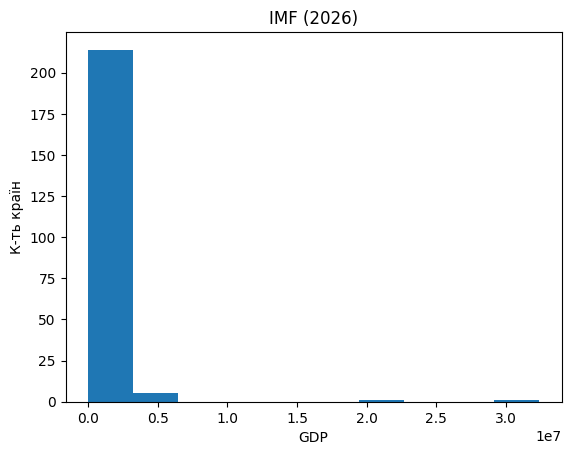

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df['IMF (2026)'], bins=10)
plt.title('IMF (2026)')
plt.xlabel('GDP')
plt.ylabel('К-ть країн')
plt.show()

абсолютна більшість країн зосереджена в лівій частині графіка з низькими показниками ВВП.
 можемо спостерігати лише одиничні випадки  країн, чиїх ВВП значно перевищує показники решти  

14.	Розрахуйте частку кожної країни в загальному значенні для кожного року (IMF (2026), World Bank (2025), United Nations (2024)).
 Як змінюються частки країн з часом (дати відповідь)?

In [ ]:
df['IMF_Share'] = df['IMF (2026)'] / df['IMF (2026)'].sum()
df['WB_Share'] = df['World Bank (2025)'] / df['World Bank (2025)'].sum()
df['UN_Share'] = df['United Nations (2024)'] / df['United Nations (2024)'].sum()

df.head(10)

/tmp/ipykernel_2855/3347587809.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['IMF_Share'] = df['IMF (2026)'] / df['IMF (2026)'].sum()
/tmp/ipykernel_2855/3347587809.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['WB_Share'] = df['World Bank (2025)'] / df['World Bank (2025)'].sum()
/tmp/ipykernel_2855/3347587809.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docu

,Country,IMF (2026),World Bank (2025),United Nations (2024),IMF_WB_Diff,std,IMF_Share,WB_Share,UN_Share
1,United States,32383920.0,30769700.0,29298000.0,1614220.0,1.465578e+07,0.238033,0.241690,0.243961
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0,9.213488e+06,0.153267,0.153153,0.156078
3,Germany,5452858.0,5050923.0,4659929.0,401935.0,2.348734e+06,0.040080,0.039674,0.038803
4,Japan,4379253.0,4435163.0,4026211.0,55910.0,2.119895e+06,0.032189,0.034837,0.033526
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0,1.876098e+06,0.031348,0.031440,0.030692
6,India,4153191.0,3956067.0,3952244.0,197124.0,1.913990e+06,0.030527,0.031074,0.032910
7,France,3596094.0,3366316.0,3160443.0,229778.0,1.582291e+06,0.026433,0.026442,0.026317
8,Italy,2738164.0,2551557.0,2380825.0,186607.0,1.194072e+06,0.020126,0.020042,0.019825
9,Russia,2656452.0,2561310.0,2173386.0,95142.0,1.202576e+06,0.019526,0.020119,0.018098
10,Brazil,2635912.0,2279920.0,2185822.0,355992.0,1.024125e+06,0.019375,0.017908,0.018201


Частки країн демонструють мінімальні коливання. Це свідчить про те, що загальна структура світової економіки та співвідношення між провідними економіками стабільні й суттєво не змінюються з часом.

15.	Візуалізуйте зміни в показниках для кожної країни за три роки на графіку. Які країни показують стабільне зростання або спад (дати відповідь)?

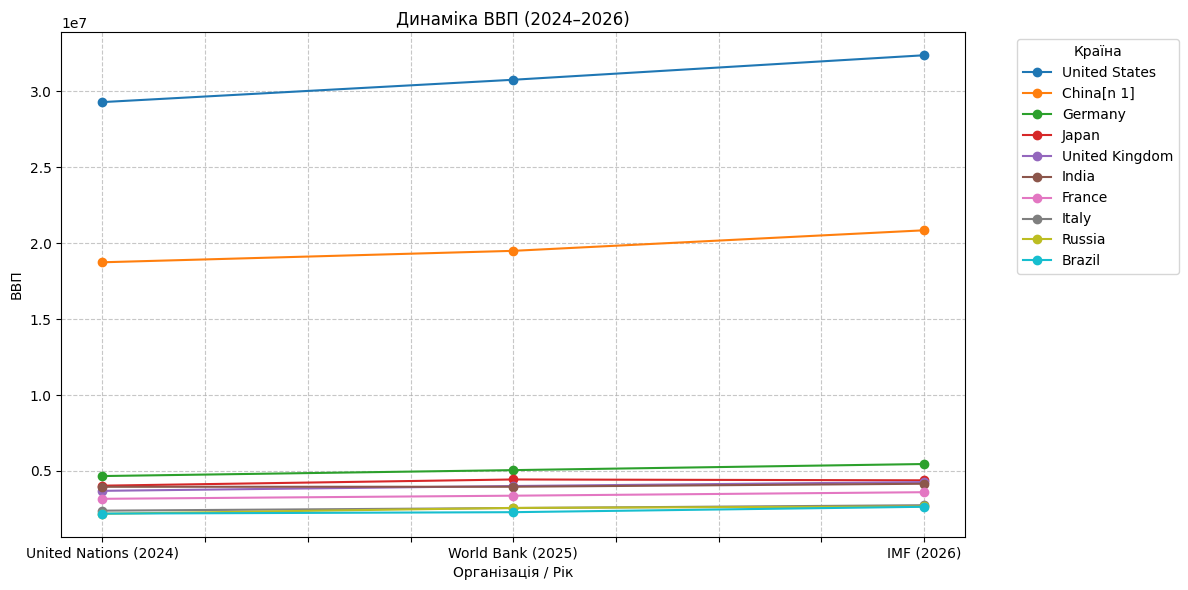

In [ ]:
top_10 = df.head(10).set_index('Country')[['United Nations (2024)', 'World Bank (2025)', 'IMF (2026)']]
top_10.T.plot(kind='line', marker='o', figsize=(12, 6))

plt.title('Динаміка ВВП (2024–2026)')
plt.xlabel('Організація / Рік')
plt.ylabel('ВВП')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Країна', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Більшість провідних економік (США, Китай, Німеччина) демонструють стабільне зростання ВВП з 2024 до 2026 року, тоді як у Японії спостерігаються незначні коливання показників.
вираженого стабільного спаду не зафіксовано.